# Bahdanau attention summarizer — raw NumPy port

A from-scratch, hand-derived-backprop port of `bahdanau_torch_rnn.ipynb`, built to
be read class-by-class next to that notebook. Two deliberate simplifications from
the PyTorch version:

- **Vanilla tanh RNN instead of GRU** in both the encoder and decoder (same role,
  much simpler backward pass — no gates to derive).
- **One example at a time**, not batched (matches `DL/lstm_numpy.ipynb`'s style and
  keeps every backward pass a plain sequence of vector/matrix ops instead of
  batch-dimension-aware ones). Since there's no batching, there's also no padding —
  each article/summary is processed at its own true length, so the encoder needs no
  padding mask.

Everything else mirrors the PyTorch notebook on purpose: same data pipeline, same
vocabulary, same `EMBEDDING_SIZE`/`HIDDEN_SIZE`, same Bahdanau attention formula,
same decoder readout (`[rnn_output ; context ; prev-token-embedding]` into the
output projection), same teacher-forcing decay and `<SOS>`-position-excluded loss
that were fixed in the PyTorch notebook.

Each class below exposes `forward`/`backward` like an `nn.Module` would (see
`gpt.ipynb` for the PyTorch-class version of this idea) — but since there's no
autograd, `forward` returns an explicit `cache` and `backward` takes that cache
back in, rather than storing it on `self`. That's required for BPTT: the whole
sequence runs forward first, and backward then replays every step in *reverse*, so
a single `self.cache` slot would only ever hold the last timestep's values.

In [6]:
import os
import random
import time
import numpy as np

random.seed(0)
np.random.seed(0)


## 1. Load BBC News Summary data (identical to `bahdanau_torch_rnn.ipynb`)

In [7]:
base_dir = "BBC News Summary"
articles_dir = os.path.join(base_dir, "News Articles")
summaries_dir = os.path.join(base_dir, "Summaries")

pairs = []
max_article_len = 40
max_summary_len = 10

categories = os.listdir(articles_dir)
for cat in categories:
    cat_article_dir = os.path.join(articles_dir, cat)
    cat_summary_dir = os.path.join(summaries_dir, cat)
    if not os.path.isdir(cat_article_dir):
        continue
    for fname in sorted(os.listdir(cat_article_dir)):
        if not fname.endswith(".txt"):
            continue
        article_path = os.path.join(cat_article_dir, fname)
        summary_path = os.path.join(cat_summary_dir, fname)
        if not os.path.exists(summary_path):
            continue
        with open(article_path, "r", encoding="latin-1") as f:
            lines = f.read().strip().split("\n")
        article = " ".join(lines[2:]) if len(lines) > 2 else lines[0]
        article_words = article.split()[:max_article_len]
        if len(article_words) < 5:
            continue
        with open(summary_path, "r", encoding="latin-1") as f:
            summary = f.read().strip()
        summary_words = summary.split()[:max_summary_len]
        if len(summary_words) < 3:
            continue
        pairs.append((" ".join(article_words).lower(), " ".join(summary_words).lower()))

print(f"Loaded {len(pairs)} article-summary pairs")

random.shuffle(pairs)
train_split = int(0.7 * len(pairs))
val_split = int(0.85 * len(pairs))
train_pairs = pairs[:train_split]
val_pairs = pairs[train_split:val_split]
test_pairs = pairs[val_split:]
print(f"Training pairs: {len(train_pairs)}, Validation pairs: {len(val_pairs)}, Test pairs: {len(test_pairs)}")


FileNotFoundError: [Errno 2] No such file or directory: 'BBC News Summary/News Articles'

In [ ]:
# Build vocabulary (same SPECIAL-token order and logic as the torch notebook)
SPECIAL = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
words = set()
for a, b in pairs:
    words.update(a.split())
    words.update(b.split())
vocab = SPECIAL + sorted(words)
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

def encode(text, add_sos=False, add_eos=False):
    ids = []
    if add_sos:
        ids.append(stoi["<SOS>"])
    for w in text.split():
        ids.append(stoi.get(w, stoi["<UNK>"]))
    if add_eos:
        ids.append(stoi["<EOS>"])
    return np.array(ids, dtype=np.int64)

# no padding/collate needed: every example keeps its own true length
train_data = [(encode(a), encode(b, True, True)) for a, b in train_pairs]
val_data = [(encode(a), encode(b, True, True)) for a, b in val_pairs]
test_data = [(encode(a), encode(b, True, True)) for a, b in test_pairs]


Vocabulary size: 16081


In [ ]:
EMBEDDING_SIZE = 128
HIDDEN_SIZE = 256
VOCAB_SIZE = vocab_size
TARGET_LEN = max_summary_len + 2

EPOCHS = 6                    # see note below the training-loop cell for why this is
                               # lower than the torch notebook's 30
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
MIN_TEACHER_FORCING = 0.5      # teacher forcing decays 1.0 -> this, same as the torch fix
GRAD_CLIP = 5.0

DTYPE = np.float32             # matches PyTorch's default dtype (and is ~2x faster
                                # here than float64, since the output-layer gradient
                                # is memory-bandwidth bound at this vocab size)


## 2. Building blocks

`Embedding`, `Linear`, and `RNNCell` are small reusable layers, the NumPy analogues
of `nn.Embedding`, `nn.Linear`, and `nn.RNN` (used here in place of `nn.GRU`, per
the "simplicity" request — a vanilla tanh cell has one gate instead of three, so its
backward pass is a single line instead of four).

In [ ]:
def xavier(shape, dtype=DTYPE):
    fan_out = shape[0]
    fan_in = shape[1] if len(shape) > 1 else shape[0]
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, size=shape).astype(dtype)


def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


In [ ]:
class Embedding:
    """NumPy analogue of nn.Embedding: a (vocab, emb) lookup table."""

    def __init__(self, vocab_size, emb_dim, dtype=DTYPE):
        self.W = xavier((vocab_size, emb_dim), dtype)
        self.dW = np.zeros_like(self.W)

    def forward(self, idx):
        return self.W[idx]

    def backward(self, idx, dvec):
        self.dW[idx] += dvec

    def zero_grad(self):
        self.dW.fill(0)

    def parameters(self):
        return [(self.W, self.dW)]

    def named_parameters(self, prefix=""):
        return [(prefix + "W", self.W)]


In [ ]:
class Linear:
    """NumPy analogue of nn.Linear: out = W @ x + b."""

    def __init__(self, in_dim, out_dim, dtype=DTYPE):
        self.W = xavier((out_dim, in_dim), dtype)
        self.b = np.zeros(out_dim, dtype=dtype)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x):
        out = self.W @ x + self.b
        return out, x  # cache = input x

    def backward(self, dout, cache):
        x = cache
        self.dW += np.outer(dout, x)
        self.db += dout
        return self.W.T @ dout

    def zero_grad(self):
        self.dW.fill(0)
        self.db.fill(0)

    def parameters(self):
        return [(self.W, self.dW), (self.b, self.db)]

    def named_parameters(self, prefix=""):
        return [(prefix + "W", self.W), (prefix + "b", self.b)]


In [ ]:
class RNNCell:
    """Vanilla tanh RNN cell (used in place of nn.GRU):
    h_t = tanh(Wxh @ x_t + Whh @ h_{t-1} + bh)
    """

    def __init__(self, input_size, hidden_size, dtype=DTYPE):
        self.Wxh = xavier((hidden_size, input_size), dtype)
        self.Whh = xavier((hidden_size, hidden_size), dtype)
        self.bh = np.zeros(hidden_size, dtype=dtype)
        self.dWxh = np.zeros_like(self.Wxh)
        self.dWhh = np.zeros_like(self.Whh)
        self.dbh = np.zeros_like(self.bh)

    def step(self, x_t, h_prev):
        z = self.Wxh @ x_t + self.Whh @ h_prev + self.bh
        h_t = np.tanh(z)
        return h_t, (x_t, h_prev, h_t)

    def step_backward(self, dh_t, cache):
        x_t, h_prev, h_t = cache
        dz = dh_t * (1 - h_t ** 2)                 # tanh backward
        self.dWxh += np.outer(dz, x_t)
        self.dWhh += np.outer(dz, h_prev)
        self.dbh += dz
        dx_t = self.Wxh.T @ dz
        dh_prev = self.Whh.T @ dz
        return dx_t, dh_prev

    def zero_grad(self):
        self.dWxh.fill(0)
        self.dWhh.fill(0)
        self.dbh.fill(0)

    def parameters(self):
        return [(self.Wxh, self.dWxh), (self.Whh, self.dWhh), (self.bh, self.dbh)]

    def named_parameters(self, prefix=""):
        return [(prefix + "Wxh", self.Wxh), (prefix + "Whh", self.Whh), (prefix + "bh", self.bh)]


## 3. Bahdanau attention

Mirrors `BahdanauAttention(nn.Module)` exactly: `energy = tanh(W_s(query) +
W_h(encoder_outputs))`, `scores = v(energy)`, softmax over the source positions,
weighted sum for the context vector. `W_s`/`W_h`/`v` are named the same as the
torch version's `nn.Linear` sub-modules (including their biases) so the two are
easy to compare line by line.

The backward pass is the one part with no PyTorch equivalent to read off — gradient
reaches the encoder states `H` through **two separate paths**: directly through the
context weighted-sum, and through the attention *scores* (since `H` is also used as
the attention "key"). Both are accumulated into the same `dH_enc`.

In [ ]:
class BahdanauAttention:
    def __init__(self, hidden_size, dtype=DTYPE):
        self.W_s = xavier((hidden_size, hidden_size), dtype)
        self.b_s = np.zeros(hidden_size, dtype=dtype)
        self.W_h = xavier((hidden_size, hidden_size), dtype)
        self.b_h = np.zeros(hidden_size, dtype=dtype)
        self.v = xavier((1, hidden_size), dtype)
        self.bv = np.zeros(1, dtype=dtype)

        self.dW_s = np.zeros_like(self.W_s)
        self.db_s = np.zeros_like(self.b_s)
        self.dW_h = np.zeros_like(self.W_h)
        self.db_h = np.zeros_like(self.b_h)
        self.dv = np.zeros_like(self.v)
        self.dbv = np.zeros_like(self.bv)

    def forward(self, decoder_hidden, encoder_outputs):
        # U[i] = tanh(W_s @ decoder_hidden + b_s + W_h @ encoder_outputs[i] + b_h)
        query_proj = self.W_s @ decoder_hidden + self.b_s          # (H,)
        keys_proj = encoder_outputs @ self.W_h.T + self.b_h        # (T_x, H)
        U = np.tanh(keys_proj + query_proj)                        # (T_x, H)
        scores = U @ self.v[0] + self.bv[0]                        # (T_x,)
        alpha = softmax(scores)                                    # (T_x,)
        context = alpha @ encoder_outputs                          # (H,)
        cache = (U, alpha, encoder_outputs, decoder_hidden)
        return context, alpha, cache

    def backward(self, dcontext, cache):
        U, alpha, H_enc, decoder_hidden = cache

        dH_enc = np.outer(alpha, dcontext)                         # context path
        dalpha = H_enc @ dcontext
        dscores = alpha * (dalpha - np.sum(alpha * dalpha))        # softmax backward

        self.dv[0] += dscores @ U
        self.dbv[0] += np.sum(dscores)
        dU = np.outer(dscores, self.v[0])
        dz = dU * (1 - U ** 2)                                     # tanh backward

        dz_sum = dz.sum(axis=0)
        self.dW_s += np.outer(dz_sum, decoder_hidden)
        self.db_s += dz_sum
        self.dW_h += dz.T @ H_enc
        self.db_h += dz_sum

        ddecoder_hidden = self.W_s.T @ dz_sum
        dH_enc += dz @ self.W_h                                    # attention-key path
        return ddecoder_hidden, dH_enc

    def zero_grad(self):
        for g in (self.dW_s, self.db_s, self.dW_h, self.db_h, self.dv, self.dbv):
            g.fill(0)

    def parameters(self):
        return [(self.W_s, self.dW_s), (self.b_s, self.db_s),
                (self.W_h, self.dW_h), (self.b_h, self.db_h),
                (self.v, self.dv), (self.bv, self.dbv)]

    def named_parameters(self, prefix=""):
        return [(prefix + "W_s", self.W_s), (prefix + "b_s", self.b_s),
                (prefix + "W_h", self.W_h), (prefix + "b_h", self.b_h),
                (prefix + "v", self.v), (prefix + "bv", self.bv)]


## 4. Encoder

Mirrors `Encoder(nn.Module)`, minus dropout and `pack_padded_sequence` — with no
batching there's no padding, so every article is just run through the RNN at its
own true length. It keeps every hidden state `H` (not just the last), since
attention needs to look back at all of them.

In [ ]:
class Encoder:
    def __init__(self, embedding, emb_dim, hidden_size, dtype=DTYPE):
        self.embedding = embedding
        self.rnn_cell = RNNCell(emb_dim, hidden_size, dtype)
        self.hidden_size = hidden_size
        self.dtype = dtype

    def forward(self, x_ids):
        T = len(x_ids)
        H = np.zeros((T, self.hidden_size), dtype=self.dtype)
        caches = []
        h_prev = np.zeros(self.hidden_size, dtype=self.dtype)
        for t in range(T):
            x_t = self.embedding.forward(x_ids[t])
            h_t, rnn_cache = self.rnn_cell.step(x_t, h_prev)
            H[t] = h_t
            caches.append((x_ids[t], rnn_cache))
            h_prev = h_t
        return H, caches

    def backward(self, dH, dh_last, caches):
        """dH: gradient into every H[t] from attention. dh_last: gradient into
        H[-1] from being used as the decoder's initial hidden state (the bridge)."""
        dh_next = dh_last
        for t in reversed(range(len(caches))):
            x_id, rnn_cache = caches[t]
            dh_total = dH[t] + dh_next
            dx_t, dh_prev = self.rnn_cell.step_backward(dh_total, rnn_cache)
            self.embedding.backward(x_id, dx_t)
            dh_next = dh_prev

    def zero_grad(self):
        self.rnn_cell.zero_grad()

    def parameters(self):
        return self.rnn_cell.parameters()

    def named_parameters(self, prefix=""):
        return self.rnn_cell.named_parameters(prefix + "rnn_cell.")


## 5. Decoder

Mirrors `Decoder(nn.Module)`: `forward_step` attends over the encoder states, runs
one RNN step over `[prev-token-embedding ; context]`, then predicts from
`[rnn_output ; context ; prev-token-embedding]` — the same three-way concat as
`fc_out` in the torch version (not just the RNN output alone).

In [ ]:
class Decoder:
    def __init__(self, embedding, emb_dim, hidden_size, vocab_size, dtype=DTYPE):
        self.embedding = embedding
        self.attention = BahdanauAttention(hidden_size, dtype)
        self.rnn_cell = RNNCell(emb_dim + hidden_size, hidden_size, dtype)
        self.fc_out = Linear(hidden_size * 2 + emb_dim, vocab_size, dtype)
        self.hidden_size = hidden_size
        self.emb_dim = emb_dim

    def step(self, input_token_id, hidden, encoder_outputs):
        embedded = self.embedding.forward(input_token_id)
        context, alpha, attn_cache = self.attention.forward(hidden, encoder_outputs)
        rnn_input = np.concatenate([embedded, context])
        hidden_new, rnn_cache = self.rnn_cell.step(rnn_input, hidden)
        pred_input = np.concatenate([hidden_new, context, embedded])
        logits, fc_cache = self.fc_out.forward(pred_input)
        cache = (input_token_id, attn_cache, rnn_cache, fc_cache)
        return logits, hidden_new, alpha, cache

    def step_backward(self, dlogits, dhidden_next, cache):
        input_token_id, attn_cache, rnn_cache, fc_cache = cache
        H, E = self.hidden_size, self.emb_dim

        dpred_input = self.fc_out.backward(dlogits, fc_cache)
        dhidden_new = dpred_input[:H] + dhidden_next
        dcontext = dpred_input[H:2 * H]
        dembedded = dpred_input[2 * H:2 * H + E].copy()

        drnn_input, dhidden_prev = self.rnn_cell.step_backward(dhidden_new, rnn_cache)
        dembedded += drnn_input[:E]
        dcontext = dcontext + drnn_input[E:]

        ddecoder_hidden, dH_enc = self.attention.backward(dcontext, attn_cache)
        dhidden_prev = dhidden_prev + ddecoder_hidden

        self.embedding.backward(input_token_id, dembedded)
        return dhidden_prev, dH_enc

    def zero_grad(self):
        self.attention.zero_grad()
        self.rnn_cell.zero_grad()
        self.fc_out.zero_grad()

    def parameters(self):
        return self.attention.parameters() + self.rnn_cell.parameters() + self.fc_out.parameters()

    def named_parameters(self, prefix=""):
        params = []
        params += self.attention.named_parameters(prefix + "attention.")
        params += self.rnn_cell.named_parameters(prefix + "rnn_cell.")
        params += self.fc_out.named_parameters(prefix + "fc_out.")
        return params


## 6. Seq2Seq

Mirrors `Seq2Seq(nn.Module)`: `forward` runs the encoder once, then unrolls the
decoder with **scheduled sampling** — feeding the true previous token with
probability `teacher_forcing_ratio`, else the model's own greedy prediction, same
as the fixed `Decoder.forward` in the torch notebook. The loss loop starts at `t=0`
predicting `tgt_ids[1]`, so — like the fixed torch version — the `<SOS>` position is
never scored (there's nothing to predict there, it's the given first input).

`greedy_decode` is the autoregressive inference path, identical in spirit to
`Seq2Seq.greedy_decode` in the torch notebook.

In [ ]:
class Seq2Seq:
    def __init__(self, vocab_size, emb_dim, hidden_size, dtype=DTYPE):
        self.embedding = Embedding(vocab_size, emb_dim, dtype)  # shared, like torch's shared_embedding
        self.encoder = Encoder(self.embedding, emb_dim, hidden_size, dtype)
        self.decoder = Decoder(self.embedding, emb_dim, hidden_size, vocab_size, dtype)

    def forward(self, src_ids, tgt_ids, teacher_forcing_ratio=1.0):
        H, enc_caches = self.encoder.forward(src_ids)
        hidden = H[-1]                              # bridge: decoder starts from encoder's last state
        loss = 0.0
        dec_caches = []
        input_token = int(tgt_ids[0])                # always start from the true <SOS>
        for t in range(len(tgt_ids) - 1):
            target_id = int(tgt_ids[t + 1])
            logits, hidden, alpha, cache = self.decoder.step(input_token, hidden, H)
            probs = softmax(logits)
            loss += -np.log(probs[target_id] + 1e-9)
            dec_caches.append((cache, probs, target_id))

            use_teacher_forcing = random.random() < teacher_forcing_ratio
            input_token = int(tgt_ids[t + 1]) if use_teacher_forcing else int(np.argmax(logits))
        loss /= max(1, len(tgt_ids) - 1)
        return loss, H, enc_caches, dec_caches

    def backward(self, H, enc_caches, dec_caches):
        dH = np.zeros_like(H)
        dhidden_next = np.zeros(H.shape[1], dtype=H.dtype)
        n = len(dec_caches)
        for t in reversed(range(n)):
            cache, probs, target_id = dec_caches[t]
            dlogits = probs.copy()
            dlogits[target_id] -= 1.0
            dlogits /= n
            dhidden_prev, dH_t = self.decoder.step_backward(dlogits, dhidden_next, cache)
            dH += dH_t
            dhidden_next = dhidden_prev
        self.encoder.backward(dH, dhidden_next, enc_caches)

    def greedy_decode(self, src_ids, sos_id, eos_id, max_len):
        H, _ = self.encoder.forward(src_ids)
        hidden = H[-1]
        token = sos_id
        tokens = []
        for _ in range(max_len):
            logits, hidden, alpha, _ = self.decoder.step(token, hidden, H)
            token = int(np.argmax(logits))
            if token == eos_id:
                break
            tokens.append(token)
        return tokens

    def zero_grad(self):
        self.embedding.zero_grad()
        self.encoder.zero_grad()
        self.decoder.zero_grad()

    def parameters(self):
        return self.embedding.parameters() + self.encoder.parameters() + self.decoder.parameters()

    def named_parameters(self):
        params = []
        params += self.embedding.named_parameters("embedding.")
        params += self.encoder.named_parameters("encoder.")
        params += self.decoder.named_parameters("decoder.")
        return params

    def state_dict(self):
        return {name: arr.copy() for name, arr in self.named_parameters()}

    def load_state_dict(self, state_dict):
        own_params = dict(self.named_parameters())
        assert set(own_params) == set(state_dict), "checkpoint parameter names do not match model"
        for name, arr in state_dict.items():
            own_params[name][...] = arr


## 7. Optimizer

A from-scratch Adam (matches `optim.Adam(model.parameters(), lr=0.001,
weight_decay=1e-5)` from the torch notebook, including L2 weight decay folded into
the gradient before the moment updates, the same way `torch.optim.Adam` does it)
plus global-norm gradient clipping per parameter array — vanilla tanh RNNs need
this more than GRUs do, since there's no gating to help gradients survive many
timesteps.

In [ ]:
class Adam:
    def __init__(self, parameters, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.weight_decay = weight_decay
        self.m = [np.zeros_like(p) for p, g in parameters]
        self.v = [np.zeros_like(p) for p, g in parameters]
        self.t = 0

    def step(self, parameters):
        self.t += 1
        for i, (p, g) in enumerate(parameters):
            g = g + self.weight_decay * p
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            p -= (self.lr * m_hat / (np.sqrt(v_hat) + self.eps)).astype(p.dtype)


def clip_grads(parameters, max_norm=GRAD_CLIP):
    for p, g in parameters:
        norm = np.linalg.norm(g)
        if norm > max_norm:
            g *= max_norm / (norm + 1e-9)


## 8. Gradient check

Verify `Decoder.step_backward` / `Encoder.backward` against finite differences
**before** trusting them to train the real model. This uses a tiny throwaway model
(small vocab/hidden size, float64) rather than the real 16081-word/256-hidden one —
float32 finite differences are too imprecise to give a clean signal, and the real
model's output layer is too expensive to call ~60 extra times just for a sanity
check. The class logic being checked is identical either way; only the sizes and
dtype differ.

In [ ]:
def gradient_check():
    rng_state = random.getstate()
    np_state = np.random.get_state()
    try:
        random.seed(1)
        np.random.seed(1)
        tiny_vocab, tiny_emb, tiny_hidden = 30, 6, 8
        check_model = Seq2Seq(tiny_vocab, tiny_emb, tiny_hidden, dtype=np.float64)
        src_ids = np.random.randint(0, tiny_vocab, size=5)
        tgt_ids = np.array([1, 4, 7, 2], dtype=np.int64)  # arbitrary <SOS> ... <EOS>-shaped sequence

        loss0, H, enc_caches, dec_caches = check_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
        check_model.zero_grad()
        check_model.backward(H, enc_caches, dec_caches)
        analytic_params = check_model.parameters()

        epsilon = 1e-5
        rng = np.random.RandomState(0)
        worst_rel_err = 0.0
        print(f"{'param shape':16s} {'index':16s} {'analytic':>12s} {'numeric':>12s} {'rel err':>10s}")
        for p, g in analytic_params:
            flat_idx = tuple(rng.randint(0, s) for s in p.shape)
            orig = p[flat_idx]

            p[flat_idx] = orig + epsilon
            loss_plus, _, _, _ = check_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
            p[flat_idx] = orig - epsilon
            loss_minus, _, _, _ = check_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
            p[flat_idx] = orig

            numeric = (loss_plus - loss_minus) / (2 * epsilon)
            analytic = g[flat_idx]
            rel_err = abs(analytic - numeric) / max(1e-8, abs(analytic) + abs(numeric))
            worst_rel_err = max(worst_rel_err, rel_err)
            print(f"{str(p.shape):16s} {str(flat_idx):16s} {analytic:12.6f} {numeric:12.6f} {rel_err:10.2e}")

        print(f"\nworst relative error across all parameter arrays: {worst_rel_err:.2e}")
        assert worst_rel_err < 1e-3, "gradient check failed - backward pass does not match finite differences"
        print("Gradient check passed.")
    finally:
        random.setstate(rng_state)
        np.random.set_state(np_state)


gradient_check()


param shape      index                analytic      numeric    rel err
(30, 6)          (12, 5)              0.000000     0.000000   0.00e+00
(8, 6)           (0, 3)              -0.017641    -0.017641   8.19e-09
(8, 8)           (3, 3)               0.016431     0.016431   1.34e-08
(8,)             (7,)                 0.038701     0.038701   2.65e-08
(8, 8)           (1, 3)               0.001317     0.001317   1.57e-08
(8,)             (5,)                 0.007635     0.007635   1.28e-08
(8, 8)           (2, 4)              -0.007259    -0.007259   1.24e-08
(8,)             (7,)                -0.002283    -0.002283   8.76e-09
(1, 8)           (0, 6)               0.015657     0.015657   1.34e-08
(1,)             (0,)                 0.000000     0.000000   6.61e-10
(8, 14)          (0, 8)              -0.007840    -0.007840   1.60e-08
(8, 8)           (4, 2)               0.024427     0.024427   2.44e-08
(8,)             (1,)                 0.102083     0.102083   1.34e-08
(30, 2

## 8.5. Quick sanity check: overfit a tiny subset

Before committing to the full ~80-90 minute run below, check that the whole pipeline
(data -> encoder -> attention -> decoder -> hand-derived backprop -> Adam) is actually
*capable* of learning anything at all. Take a small subset (100 pairs), build a
vocabulary from just those words, and use smaller `EMBEDDING_SIZE`/`HIDDEN_SIZE` for
this experiment only - and train with **no train/val split and no early stopping**,
just a fixed 100 epochs, checking whether the model can reproduce (memorize) the
summaries it was trained on.

Two things made the first version of this too slow (it was on pace for ~80+ min, no
faster than the full run):
1. **BLAS thread oversubscription.** OpenBLAS defaults to spawning up to 12 threads
   per matmul on this machine. For the tiny per-timestep matrices here (a few hundred
   floats), thread spawn/sync overhead swamps the actual math - single-threaded BLAS
   is faster. `threadpoolctl.threadpool_limits(1)` fixes this for just this cell,
   without touching the full run's threading below (its `fc_out` matmul is much
   bigger and can actually benefit from multiple threads).
2. **Vocab/dims not shrunk enough.** Subsetting rows alone still left `fc_out` sized
   by the subset's vocab (~2700 words) at the full `HIDDEN_SIZE=256`. Here both the
   sample count and `EMBEDDING_SIZE`/`HIDDEN_SIZE` are reduced, verified by direct
   timing to finish 100 epochs in well under 5 minutes.

- If it can't even reproduce summaries for data it was trained directly on, that's a
  real implementation bug, not a data-scarcity issue.
- If it can, the full-dataset run's weak generations are "1557 examples isn't enough
  data / not enough epochs / not enough capacity," not broken code.

This uses a fresh, separate model instance (`overfit_model`) - it does not touch
`model`, `train_data`, `val_data`, or `test_data` used by the full run below.

In [ ]:
# --- Overfit sanity check: small subset, no val/early stopping, tuned to run fast ---
OVERFIT_N = 100                # total rows, no train/val/test split
OVERFIT_EPOCHS = 100           # fixed count, no early stopping - we WANT to overfit here
OVERFIT_EMBEDDING_SIZE = 64    # smaller than the real EMBEDDING_SIZE=128, just for this check
OVERFIT_HIDDEN_SIZE = 128      # smaller than the real HIDDEN_SIZE=256, just for this check

random.seed(0)
overfit_pairs = random.sample(pairs, OVERFIT_N)

# Vocab built only from this subset - this (plus the smaller dims above) is what
# makes it fast: fc_out shrinks from vocab_size x (2*HIDDEN_SIZE+EMBEDDING_SIZE) down
# to a small fraction of that.
overfit_words = set()
for a, b in overfit_pairs:
    overfit_words.update(a.split())
    overfit_words.update(b.split())
overfit_vocab = SPECIAL + sorted(overfit_words)
overfit_stoi = {w: i for i, w in enumerate(overfit_vocab)}
overfit_itos = {i: w for w, i in overfit_stoi.items()}
overfit_vocab_size = len(overfit_vocab)


def overfit_encode(text, add_sos=False, add_eos=False):
    ids = []
    if add_sos:
        ids.append(overfit_stoi["<SOS>"])
    for w in text.split():
        ids.append(overfit_stoi.get(w, overfit_stoi["<UNK>"]))
    if add_eos:
        ids.append(overfit_stoi["<EOS>"])
    return np.array(ids, dtype=np.int64)


overfit_data = [(overfit_encode(a), overfit_encode(b, True, True)) for a, b in overfit_pairs]

full_fc_out = vocab_size * (2 * HIDDEN_SIZE + EMBEDDING_SIZE)
overfit_fc_out = overfit_vocab_size * (2 * OVERFIT_HIDDEN_SIZE + OVERFIT_EMBEDDING_SIZE)
print(f"Overfit subset: {len(overfit_data)} pairs, vocab size: {overfit_vocab_size} (vs {vocab_size} full)")
print(f"fc_out shrinks from {full_fc_out:,} elements to {overfit_fc_out:,} elements "
      f"({full_fc_out / overfit_fc_out:.0f}x smaller)")


Overfit subset: 100 pairs, vocab size: 2050 (vs 16081 full)
fc_out shrinks from 10,291,840 elements to 656,000 elements (16x smaller)


In [ ]:
import threadpoolctl

overfit_model = Seq2Seq(overfit_vocab_size, OVERFIT_EMBEDDING_SIZE, OVERFIT_HIDDEN_SIZE, dtype=DTYPE)
overfit_optimizer = Adam(overfit_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

start = time.time()
with threadpoolctl.threadpool_limits(limits=1, user_api="blas"):
    # Single-threaded BLAS: these matmuls are tiny, so thread spawn/sync overhead
    # would otherwise dominate (see markdown note above) - this alone was the main
    # fix for the "still taking too much time" slowdown.
    for epoch in range(1, OVERFIT_EPOCHS + 1):
        random.shuffle(overfit_data)
        total_loss = 0.0
        for src_ids, tgt_ids in overfit_data:
            # No teacher-forcing decay here - we WANT this to overfit as easily as
            # possible, so stay fully teacher-forced for all 100 epochs.
            loss, H, enc_caches, dec_caches = overfit_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
            overfit_model.zero_grad()
            overfit_model.backward(H, enc_caches, dec_caches)
            params = overfit_model.parameters()
            clip_grads(params)
            overfit_optimizer.step(params)
            total_loss += loss

        train_loss = total_loss / len(overfit_data)
        if epoch == 1 or epoch % 10 == 0 or epoch == OVERFIT_EPOCHS:
            elapsed = time.time() - start
            print(f"Epoch {epoch}/{OVERFIT_EPOCHS}  train loss: {train_loss:.4f}  elapsed: {elapsed:.1f}s")

print(f"\nDone in {time.time() - start:.1f}s")


Epoch 1/100  train loss: 6.8058  elapsed: 1.8s


Epoch 10/100  train loss: 2.6748  elapsed: 17.6s


Epoch 20/100  train loss: 0.1602  elapsed: 35.0s


Epoch 30/100  train loss: 0.0335  elapsed: 52.0s


Epoch 40/100  train loss: 0.0147  elapsed: 69.9s


...

Epoch 60/100  train loss: 0.0066  elapsed: 104.0s


Epoch 70/100  train loss: 0.0042  elapsed: 121.8s


Epoch 80/100  train loss: 0.0031  elapsed: 138.7s


Epoch 90/100  train loss: 0.0026  elapsed: 155.1s


Epoch 100/100  train loss: 0.0023  elapsed: 171.8s

Done in 171.8s


In [ ]:
def overfit_summarize_ids(src_ids):
    tokens = overfit_model.greedy_decode(src_ids, overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], max_len=TARGET_LEN)
    return " ".join(overfit_itos[i] for i in tokens
                     if i not in (overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], overfit_stoi["<PAD>"]))


def overfit_ids_to_text(ids):
    return " ".join(overfit_itos[int(i)] for i in ids
                     if int(i) not in (overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], overfit_stoi["<PAD>"]))


exact_matches = 0
sample = overfit_data[:15]
for src_ids, tgt_ids in sample:
    predicted = overfit_summarize_ids(src_ids)
    actual = overfit_ids_to_text(tgt_ids)
    if predicted == actual:
        exact_matches += 1
    print(f"Article: {overfit_ids_to_text(src_ids)}")
    print(f"Actual Summary: {actual}")
    print(f"Predicted: {predicted}")
    print("=" * 50)

print(f"\nExact match on shown sample: {exact_matches}/{len(sample)}")
print("If most predictions closely match (or exactly match) their actual summaries, "
      "the architecture and backprop are working - the full-dataset run's weaker "
      "output is a data-scarcity/epoch-budget issue, not a bug.")


Article: surfers outside the us have been unable to visit the official re-election site of president george w bush. the blocking of browsers sited outside the us began in the early hours of monday morning. since then people outside the us
Actual Summary: since then people outside the us trying to browse the
Predicted: since then people outside the us trying to browse the
Article: eurosceptic party ukip have suspended a candidate for allegedly suggesting the criminally insane should be killed. john houston, 54, was due to stand in the east kilbride seat in lanarkshire at the next election. but he was suspended after his
Actual Summary: peter nielson, who is ukip scotland chairman, said he had
Predicted: peter nielson, who is ukip scotland chairman, said he had
Article: labour's leadership put on a show of unity at a campaign poster launch after mps criticised tony blair and gordon brown over reports of their rift. mr brown was joined at the launch by john prescott and alan milburn, the


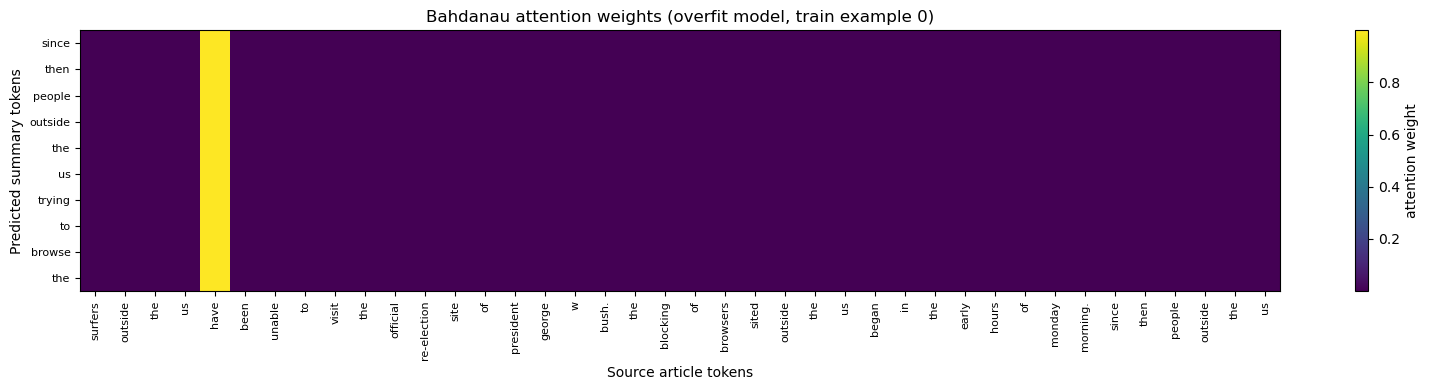

Predicted: since then people outside the us trying to browse the
Actual:    since then people outside the us trying to browse the


In [ ]:
import matplotlib.pyplot as plt


def decode_with_attention(model, src_ids, sos_id, eos_id, max_len):
    """Same as Seq2Seq.greedy_decode, but also collects the attention weights
    (alpha) at every decoder step, for visualization."""
    H, _ = model.encoder.forward(src_ids)
    hidden = H[-1]
    token = sos_id
    tokens = []
    alphas = []
    for _ in range(max_len):
        logits, hidden, alpha, _ = model.decoder.step(token, hidden, H)
        token = int(np.argmax(logits))
        if token == eos_id:
            break
        tokens.append(token)
        alphas.append(alpha)
    return tokens, np.array(alphas)  # (tgt_len, src_len)


src_ids, tgt_ids = overfit_data[0]
pred_tokens, attn_matrix = decode_with_attention(
    overfit_model, src_ids, overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], max_len=TARGET_LEN
)
src_words = [overfit_itos[int(i)] for i in src_ids]
pred_words = [overfit_itos[t] for t in pred_tokens]

fig, ax = plt.subplots(figsize=(max(8, len(src_words) * 0.4), max(4, len(pred_words) * 0.4)))
im = ax.imshow(attn_matrix, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(src_words)))
ax.set_xticklabels(src_words, rotation=90, fontsize=8)
ax.set_yticks(range(len(pred_words)))
ax.set_yticklabels(pred_words, fontsize=8)
ax.set_xlabel("Source article tokens")
ax.set_ylabel("Predicted summary tokens")
ax.set_title("Bahdanau attention weights (overfit model, train example 0)")
fig.colorbar(im, ax=ax, label="attention weight")
fig.tight_layout()
plt.show()

print(f"Predicted: {' '.join(pred_words)}")
print(f"Actual:    {overfit_ids_to_text(tgt_ids)}")


In [ ]:
import json

OVERFIT_CHECKPOINT_DIR = "DL/checkpoints"
os.makedirs(OVERFIT_CHECKPOINT_DIR, exist_ok=True)
OVERFIT_WEIGHTS_PATH = os.path.join(OVERFIT_CHECKPOINT_DIR, "bahdanau_numpy_overfit.npz")
OVERFIT_META_PATH = os.path.join(OVERFIT_CHECKPOINT_DIR, "bahdanau_numpy_overfit_meta.json")

np.savez(OVERFIT_WEIGHTS_PATH, **overfit_model.state_dict())
with open(OVERFIT_META_PATH, "w") as f:
    json.dump({
        "stoi": overfit_stoi,
        "EMBEDDING_SIZE": OVERFIT_EMBEDDING_SIZE,
        "HIDDEN_SIZE": OVERFIT_HIDDEN_SIZE,
        "VOCAB_SIZE": overfit_vocab_size,
        "TARGET_LEN": TARGET_LEN,
    }, f)

print(f"Saved overfit model weights to {OVERFIT_WEIGHTS_PATH}")
print(f"Saved overfit vocab/config to {OVERFIT_META_PATH}")


Saved overfit model weights to DL/checkpoints/bahdanau_numpy_overfit.npz
Saved overfit vocab/config to DL/checkpoints/bahdanau_numpy_overfit_meta.json


## 9. Model, evaluation, and training loop

Instantiate the real model at the torch notebook's actual sizes
(`EMBEDDING_SIZE=128`, `HIDDEN_SIZE=256`, full 16081-word vocabulary).

In [ ]:
model = Seq2Seq(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE, dtype=DTYPE)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(f"Total parameter arrays: {len(model.parameters())}")
print(f"Total parameters: {sum(p.size for p, g in model.parameters()):,}")


Total parameter arrays: 15
Total parameters: 12,760,786


In [ ]:
def evaluate(data, teacher_forcing_ratio=1.0):
    total_loss = 0.0
    for src_ids, tgt_ids in data:
        loss, _, _, _ = model.forward(src_ids, tgt_ids, teacher_forcing_ratio=teacher_forcing_ratio)
        total_loss += loss
    return total_loss / len(data)


In [ ]:
# NOTE on EPOCHS: the torch notebook trains for 30 epochs in a couple of minutes,
# because PyTorch batches examples and runs on optimized batched GEMM kernels. Here,
# each example is processed one at a time in plain Python, and the dominant cost is
# the output-layer gradient: fc_out is (VOCAB_SIZE, HIDDEN_SIZE*2+EMBEDDING_SIZE) =
# (16081, 640) - a ~10.3M-element array that gets a fresh outer-product gradient at
# *every* decoder step, of *every* example, of *every* epoch. That single line is
# memory-bandwidth bound and dominates the runtime; there's no way to avoid it
# without either batching (which was explicitly ruled out for backprop simplicity)
# or shrinking the vocabulary (which would stop this being a faithful port). So
# EPOCHS is set lower than the torch notebook's 30 to keep this a background job of
# roughly ~1.5 hours rather than ~7 - bump it up and rerun this cell if you want to
# let it train longer.
start = time.time()
for epoch in range(1, EPOCHS + 1):
    random.shuffle(train_data)
    total_loss = 0.0
    # decay teacher forcing linearly from 1.0 to MIN_TEACHER_FORCING, same as the torch fix
    teacher_forcing_ratio = 1.0 - (1.0 - MIN_TEACHER_FORCING) * ((epoch - 1) / max(1, EPOCHS - 1))
    for src_ids, tgt_ids in train_data:
        loss, H, enc_caches, dec_caches = model.forward(src_ids, tgt_ids, teacher_forcing_ratio)
        model.zero_grad()
        model.backward(H, enc_caches, dec_caches)
        params = model.parameters()
        clip_grads(params)
        optimizer.step(params)
        total_loss += loss

    train_loss = total_loss / len(train_data)
    val_loss = evaluate(val_data)  # teacher_forcing_ratio=1.0, matches the torch evaluate()
    elapsed_min = (time.time() - start) / 60
    print(f"Epoch {epoch}/{EPOCHS}  train loss: {train_loss:.4f}  val loss: {val_loss:.4f}  "
          f"TF ratio: {teacher_forcing_ratio:.2f}  elapsed: {elapsed_min:.1f} min")


Epoch 1/6  train loss: 7.1384  val loss: 6.6614  TF ratio: 1.00  elapsed: 12.3 min


Epoch 2/6  train loss: 5.9472  val loss: 6.7844  TF ratio: 0.90  elapsed: 25.8 min


Epoch 3/6  train loss: 5.2537  val loss: 6.8002  TF ratio: 0.80  elapsed: 38.8 min


Epoch 4/6  train loss: 4.7037  val loss: 6.8270  TF ratio: 0.70  elapsed: 51.1 min


Epoch 5/6  train loss: 4.2693  val loss: 6.8828  TF ratio: 0.60  elapsed: 66.3 min


Epoch 6/6  train loss: 3.9853  val loss: 7.0199  TF ratio: 0.50  elapsed: 81.2 min


## 11. Save / load the trained model

Each class exposes `named_parameters()` (mirrors `nn.Module.named_parameters()`), and `Seq2Seq.state_dict()`/`load_state_dict()` build on it the same way PyTorch's do. Weights are saved with `np.savez` (one array per named parameter); the vocabulary and hyperparameters needed to reconstruct the architecture are saved alongside as JSON, since unlike `torch.load`, `np.load` only knows about arrays.

In [ ]:
import json

CHECKPOINT_DIR = "DL/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
WEIGHTS_PATH = os.path.join(CHECKPOINT_DIR, "bahdanau_numpy.npz")
META_PATH = os.path.join(CHECKPOINT_DIR, "bahdanau_numpy_meta.json")

np.savez(WEIGHTS_PATH, **model.state_dict())
with open(META_PATH, "w") as f:
    json.dump({
        "stoi": stoi,
        "EMBEDDING_SIZE": EMBEDDING_SIZE,
        "HIDDEN_SIZE": HIDDEN_SIZE,
        "VOCAB_SIZE": VOCAB_SIZE,
        "TARGET_LEN": TARGET_LEN,
    }, f)

print(f"Saved weights to {WEIGHTS_PATH}")
print(f"Saved vocab/config to {META_PATH}")

NameError: name 'model' is not defined

In [ ]:
# --- Demonstrate loading the saved checkpoint into a fresh model and running inference ---
def load_checkpoint(weights_path, meta_path):
    with open(meta_path) as f:
        meta = json.load(f)
    loaded_stoi = meta["stoi"]
    loaded_itos = {int(i): w for w, i in loaded_stoi.items()}
    loaded_model = Seq2Seq(meta["VOCAB_SIZE"], meta["EMBEDDING_SIZE"], meta["HIDDEN_SIZE"], dtype=DTYPE)
    data = np.load(weights_path)
    loaded_model.load_state_dict({k: data[k] for k in data.files})
    return loaded_model, loaded_stoi, loaded_itos, meta["TARGET_LEN"]

loaded_model, loaded_stoi, loaded_itos, loaded_target_len = load_checkpoint(WEIGHTS_PATH, META_PATH)

# sanity check: loaded model should produce identical greedy-decode output to `model`
src_ids, tgt_ids = test_data[0]
original_tokens = model.greedy_decode(src_ids, stoi["<SOS>"], stoi["<EOS>"], max_len=TARGET_LEN)
loaded_tokens = loaded_model.greedy_decode(src_ids, loaded_stoi["<SOS>"], loaded_stoi["<EOS>"], max_len=loaded_target_len)
print("original :", " ".join(itos[i] for i in original_tokens if i not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"])))
print("loaded   :", " ".join(loaded_itos[i] for i in loaded_tokens if i not in (loaded_stoi["<SOS>"], loaded_stoi["<EOS>"], loaded_stoi["<PAD>"])))
assert original_tokens == loaded_tokens, "loaded model does not match original - checkpoint round-trip failed"
print("\nCheckpoint round-trip verified: loaded model produces identical output.")

original : g thomas (toulouse, capt); k t (newport-gwent), t shanklin (cardiff),
loaded   : g thomas (toulouse, capt); k t (newport-gwent), t shanklin (cardiff),

Checkpoint round-trip verified: loaded model produces identical output.


## 10. Qualitative evaluation (mirrors the torch notebook's two test cells)

In [ ]:
def summarize_ids(src_ids):
    tokens = model.greedy_decode(src_ids, stoi["<SOS>"], stoi["<EOS>"], max_len=TARGET_LEN)
    return " ".join(itos[i] for i in tokens if i not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"]))


def ids_to_text(ids):
    return " ".join(itos[int(i)] for i in ids if int(i) not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"]))


for src_ids, tgt_ids in test_data:
    predicted = summarize_ids(src_ids)
    print(f"Article: {ids_to_text(src_ids)}")
    print(f"Actual Summary: {ids_to_text(tgt_ids)}")
    print(f"Predicted: {predicted}")
    print("=" * 50)


Article: wales coach mike ruddock says england lock danny grewcock needs to review his actions after he kicked dwayne peel. trouble flared at a ruck in the first half of wales' 11-9 win in cardiff as grewcock came recklessly over the
Actual Summary: wales coach mike ruddock says england lock danny grewcock needs
Predicted: g thomas (toulouse, capt); k t (newport-gwent), t shanklin (cardiff),
Article: next has said its annual profit will be â£5m lower than previously expected because its end-of-year clearance sale has proved disappointing. "clearance rates in our end-of-season sale have been below our expectations," the company said. the high street retailer said
Actual Summary: next chief executive simon wolfson admitted that festive sales were
Predicted: the administrators said that nearly 70% to an g8 to
Article: uk sportswear firm umbro has posted a 222% rise in annual profit after sales of replica england football kits were boosted by the euro 2004 tournament. pre-tax profit for 20

Article: italy coach john kirwan believes his side can upset england as the six nations wooden spoon battle hots up. the two sides, both without a win, meet on 12 march at twickenham and kirwan says his side will be hoping
Actual Summary: "we have to make sure the england and france games
Predicted: now italians italians travel to edinburgh hoping to claim their
Article: the tories say plans to extend pub opening times should be put on hold until binge drinking is under control, despite backing a law change last year. spokesman david davis said ministers had failed to make his party aware of
Actual Summary: the government would go ahead with the changes which would
Predicted: the us film is to the the the to the


Article: the once-famous commodore computer brand could be resurrected after being bought by a us-based digital music distributor. new owner yeahronimo media ventures has not ruled out the possibility of a new breed of commodore computers. it also plans to develop
Actual Summary: in the chronology of home computing, commodore was one of
Predicted: the us film is to the the the to the
Article: one in 10 adult americans - equivalent to 22 million people - owns an mp3 player, according to a survey. a study by the pew internet and american life project found that mp3 players are the gadget of choice among
Actual Summary: one in 10 adult americans - equivalent to 22 million
Predicted: the administrators told bbc news - equivalent selling argonaut news
Article: the green party is concerned thousands of residents may not be able to vote in edinburgh's transport referendum. edinburgh city council is to ballot constituents on proposals to introduce congestion charging in the capital. but green 

Article: australian mining firm wmc resources has said it is worth up to 30% more than a hostile 7.4bn australian dollar ($5.8bn; â£3bn) bid by rival xstrata. there is now pressure on swiss-based xstrata to increase its takeover offer. a report
Actual Summary: grant samuel said its valuation of wmc was based on
Predicted: qantas boss of the shoppers was still want to the
Article: latin america's economy grew by 5.5% in 2004, its best performance since 1980, while exports registered their best performance in two decades. the united nations' economic commission for latin america and the caribbean said the region grew by 5.5% this
Actual Summary: the united nations' economic commission for latin america and the
Predicted: the administrators has is to the first in the to


Article: referee graham poll said he applied the laws of the game in allowing arsenal striker thierry henry's free-kick in sunday's 2-2 draw with chelsea. keeper petr cech was organising his defensive wall when henry's quick free-kick flew in, which angered
Actual Summary: referee graham poll said he applied the laws of the
Predicted: the us has signed a reduction in the sixth on
Article: the economic targets set out at the lisbon summit of european union leaders in 2000 were meant to help europe leapfrog its way past the united states to become the world's leading economy by 2010. but the lisbon targets are
Actual Summary: that's why the kok report recommends that the lisbon targets
Predicted: the us film is to the the the to the
Article: carlos moya has chosen not to help spain try and defend the davis cup crown they won in seville in november. moya led spain to victory over the usa but wants to focus on the grand slams in 2005, although
Actual Summary: moya led spain to victory over

...

Article: computer users across the world continue to ignore security warnings about spam e-mails and are being lured into buying goods, a report suggests. more than a quarter have bought software through spam e-mails and 24% have bought clothes or jewellery.
Actual Summary: a third of them read unsolicited junk e-mail and 66%
Predicted: ibm has been been past 12 years ibm has been
Article: british film director sir alan parker has been made an officer in the order of arts and letters, one of france's highest cultural honours. sir alan received his decoration in paris on wednesday from french culture minister renaud donnedieu de
Actual Summary: "you have explored the possibilities of film with an immense
Predicted: "the tracking thing that speed 18% of downloaders were to
Article: organisers say this year's berlin film festival, which opens on thursday with period epic man to man, will celebrate a revitalised european cinema. of the 21 films in competition for the golden and silver bear

Article: mark philippoussis withdrew from the sydney international tennis tournament as expected on sunday after suffering a groin injury during the hopman cup. his participation in the australian open, which begins on 17 january in melbourne, also remains in doubt. defending
Actual Summary: defending women's champion justine henin-hardenne is also out of the
Predicted: mark lewis-francis has him determined lewis-francis lewis-francis 4x100m him determined
Article: the number of british films produced in the uk fell 40% in 2004, with movies starring johnny depp and jude law among those affected, screen daily has said. twenty-seven british films were made in the uk last year following a
Actual Summary: the uk film council said the drop was partly due
Predicted: the us film is to the the the to the
Article: india has raised the limit for foreign direct investment in telecoms companies from 49% to 74%. communications minister dayanidhi maran said that there is a need to fund the fast-grow

Article: controversy and lawrence dallaglio have never been very far away from each other throughout a glittering international career. even the end of his nine-year career came out of the blue, just four days before the start of the season. but
Actual Summary: to supporters of england, dallaglio could do no wrong.dallaglio arrived
Predicted: the administrators has is to the first in the to
Article: nissan has named a lifetime employee to run its operations after carlos ghosn, its highly successful boss, takes charge at renault. as chief operating officer, toshiyuki shiga will run nissan on a daily basis, although mr ghosn, who masterminded its
Actual Summary: mr ghosn transformed nissan into a fast-growing and profitable business.in
Predicted: the administrators has is to the first in the to
Article: a major change of direction is needed in britain if it is to prosper, the shadow chancellor said as the tory party spring conference began. oliver letwin said the uk could not compete wit

Article: former northern ireland minister sir nicholas scott has died at a london hospice, his family has announced. the former conservative mp for kensington and chelsea, died after a long illness diagnosed as alzheimer's. the 71-year-old served in northern ireland from
Actual Summary: former northern ireland minister sir nicholas scott has died at
Predicted: "it was a hell of a short became a gurkhas
Article: betty boothroyd has said the house of lords needs its own speaker and that peers should lead the way on reforming the upper chamber. baroness boothroyd, who was the first woman to be commons speaker, said she believed tony blair
Actual Summary: the lord chancellor currently has the role of house of
Predicted: the lord chancellor currently currently has the role in the
Article: liverpool forward milan baros is uncertain whether he remains part of boss rafa benitez's plans after being dropped for the carling cup final. baros, who is liverpool's leading scorer this season, denied r

Article: a tv station in the us has refused to show a controversial new series where adopted children try and pick their birth father - and win a cash prize. the wraz-tv fox affiliate in north carolina was the only one
Actual Summary: it was met with protests by the national council for
Predicted: the henry will not be a us and leroi's law
Article: older people and women are increasingly taking charge of protecting home computers against malicious net attacks, according to a two-year study. the number of women buying programs to protect pcs from virus, spam and spyware attacks rose by 11.2% each
Actual Summary: it is thought that 40% of those buying home net
Predicted: the administrators has is to the first in the to
Article: sci-fi shooter doom 3 has blasted away the competition at a major games ceremony, the golden joystick awards. it was the only title to win twice, winning ultimate game of the year and best pc game at the awards, presented
Actual Summary: it was the only title to w

In [ ]:
for src_ids, tgt_ids in train_data[:10]:
    predicted = summarize_ids(src_ids)
    print(f"Article: {ids_to_text(src_ids)}")
    print(f"Actual Summary: {ids_to_text(tgt_ids)}")
    print(f"Predicted: {predicted}")
    print("=" * 50)


Article: swiss drugmaker novartis has announced 5.65bn euros ($7.4bn; â£3.9bn) of purchases to make its sandoz unit the world's biggest generic drug producer. novartis, which last month forecast record sales for 2005, said it had bought all of germany's hexal. it
Actual Summary: swiss drugmaker novartis has announced 5.65bn euros ($7.4bn; â£3.9bn) of
Predicted: holcim, the world's second-biggest will have been systems, in the
Article: bt has moved to pre-empt a possible break-up of its business by offering to cut wholesale broadband prices and open its network to rivals. the move comes after telecom regulator ofcom said in november that the firm must offer competitors
Actual Summary: "central to the proposals are plans by bt to offer
Predicted: bt is offering customers free internet telephone calls to involved
Article: tony blair has backed chancellor gordon brown's pre-budget report amid opposition claims he was too bullish about the state of the uk economy. in a speech in edinburgh, 

Article: telecoms equipment supplier ericsson has posted a rise in fourth quarter profits thanks to clients like deutsche telekom upgrade their networks. operating profit in the three months to 31 december was 9.5bn kronor (â£722m; $1.3bn) against 6.3bn kronor last year.
Actual Summary: for the whole of 2004, ericsson returned a net profit
Predicted: analysts said that the ifo a have a profit in


## 12. Summarize your own article

Paste or type any news-style text into `custom_article` below and run the cell to get
a generated summary. Uses the real, full-vocab `model` trained in section 9 (same
`stoi`/`itos`/`TARGET_LEN`/`max_article_len` it was trained with).

Notes:
- Text is lowercased and truncated to the first `max_article_len` (40) words, exactly
  like the training preprocessing.
- Any word not in the 16081-word training vocabulary becomes `<UNK>` - the cell prints
  how many words were unknown, so you can tell if that's hurting the output.
- This model was only trained 6 epochs on 1557 examples, so - as seen in section 10's
  qualitative outputs - expect generic/repetitive summaries rather than sharp ones;
  see the overfit sanity check in section 8.5 for a demonstration that the *pipeline*
  itself works correctly.
- If you restarted the kernel and only ran the checkpoint cells (not the full training
  loop), swap `model`/`stoi`/`itos`/`TARGET_LEN` below for `loaded_model`/`loaded_stoi`/
  `loaded_itos`/`loaded_target_len` from the "Save / load" section instead.

In [ ]:
def encode_custom_article(text, stoi_map, max_len):
    words = text.lower().split()[:max_len]
    ids = np.array([stoi_map.get(w, stoi_map["<UNK>"]) for w in words], dtype=np.int64)
    return ids, words


custom_article = """
Apple unveiled its latest iPhone on Tuesday, featuring a faster processor and an
improved camera system. The company said the new model would go on sale next month
starting at $999. Analysts expect strong demand despite a slowing smartphone market.
"""

src_ids, kept_words = encode_custom_article(custom_article, stoi, max_article_len)
n_unk = int(np.sum(src_ids == stoi["<UNK>"]))

tokens = model.greedy_decode(src_ids, stoi["<SOS>"], stoi["<EOS>"], max_len=TARGET_LEN)
summary = " ".join(itos[t] for t in tokens if t not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"]))

print(f"Article (truncated to {len(kept_words)}/{max_article_len} words, {n_unk} unknown to vocab):")
print(" ".join(kept_words))
print()
print("Generated summary:")
print(summary)


In [ ]:
src_ids, kept_words = encode_custom_article(custom_article, stoi, max_article_len)
n_unk = int(np.sum(src_ids == stoi["<UNK>"]))

tokens = model.greedy_decode(src_ids, stoi["<SOS>"], stoi["<EOS>"], max_len=TARGET_LEN)
summary = " ".join(itos[t] for t in tokens if t not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"]))

print(f"Article (truncated to {len(kept_words)}/{max_article_len} words, {n_unk} unknown to vocab):")
print(" ".join(kept_words))
print()
print("Generated summary:")
print(summary)